# Arabic Media Bias Detection — ARBERT Fine-tuning

**Runtime**: Google Colab (T4 GPU recommended)  
**Model**: UBC-NLP/ARBERTv2  
**Task**: Binary classification — Non-biased (0) vs Biased (1)

---

### Quick-start
1. Go to **Runtime → Change runtime type → T4 GPU**
2. Run all cells top to bottom (`Runtime → Run all`)
3. Choose your experiment in **Cell 4**

No Google Drive required. Everything runs inside this Colab instance.

## Cell 1 — GPU check

In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

if device == 'cuda':
    print(f'✅ GPU ready: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU detected.')
    print('   Training will work but will be slow (~30 min/epoch).')
    print('   Recommended: Runtime → Change runtime type → T4 GPU')

✅ GPU ready: Tesla T4


## Cell 2 — Install dependencies

In [2]:
# Install required packages.
# NOTE: You may see a warning about fsspec version conflict with gcsfs.
# This is a pre-existing Colab environment conflict — it does NOT affect
# this project. The pipeline does not use gcsfs or Google Cloud Storage.

print('Installing packages...')
import subprocess, sys

packages = [
    'transformers==4.44.2',
    'accelerate>=0.30.0',
    'evaluate>=0.4.0',
    'scikit-learn>=1.3.0',
    'pandas>=2.0.0',
    'seaborn>=0.12.0',
    'pyyaml>=6.0',
]

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q'] + packages,
    capture_output=True, text=True
)

if result.returncode != 0:
    print('❌ pip install failed:')
    print(result.stderr[-3000:])  # last 3000 chars
    raise RuntimeError('Package installation failed. See error above.')

# Print any non-fsspec warnings so real issues are visible
for line in result.stderr.splitlines():
    if 'fsspec' not in line and line.strip():
        print(line)

print('✅ All packages installed.')

Installing packages...
✅ All packages installed.


## Cell 3 — Clone repository

In [3]:
import os, subprocess, sys
from pathlib import Path

REPO_URL = 'https://github.com/Abjasser/arabic-bias-detection.git'
REPO_DIR = 'arabic-bias-detection'

# ── Clone or update ────────────────────────────────────────────────────────
if Path(REPO_DIR).is_dir():
    print(f'Repository already exists — pulling latest changes...')
    result = subprocess.run(
        ['git', '-C', REPO_DIR, 'pull'],
        capture_output=True, text=True
    )
else:
    print(f'Cloning {REPO_URL} ...')
    result = subprocess.run(
        ['git', 'clone', REPO_URL],
        capture_output=True, text=True
    )

if result.returncode != 0:
    print('❌ Git operation failed:')
    print(result.stderr)
    raise RuntimeError(
        'Could not clone the repository.\n'
        'Possible causes:\n'
        '  • No internet connection in this Colab session\n'
        '  • Repository URL has changed\n'
        f'URL tried: {REPO_URL}'
    )

print(result.stdout.strip() or result.stderr.strip())

# ── Move into the repository folder ────────────────────────────────────────
if not Path(REPO_DIR).is_dir():
    raise RuntimeError(
        f'Expected directory "{REPO_DIR}" was not created by git clone.\n'
        'This should not happen — please re-run this cell.'
    )

os.chdir(REPO_DIR)

# ── Add src/ to Python path so imports work ────────────────────────────────
repo_root = str(Path.cwd())
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print(f'✅ Working directory: {Path.cwd()}')
print(f'   Files: {[f.name for f in Path(".").iterdir() if not f.name.startswith(".")]}')

Cloning https://github.com/Abjasser/arabic-bias-detection.git ...
Cloning into 'arabic-bias-detection'...
✅ Working directory: /content/arabic-bias-detection
   Files: ['notebooks', 'create_eval_csv.py', 'requirements.txt', 'data', 'README.md', 'configs', 'src']


## Cell 4 — Choose experiment

In [4]:
# ── Select one experiment ──────────────────────────────────────────────────
# EXPERIMENT = 'configs/baseline_gpt_only.yaml'     # Experiment A: GPT-only
EXPERIMENT  = 'configs/main_gpt_claude_mixed.yaml'  # Experiment B: GPT + Claude  ← DEFAULT
# ──────────────────────────────────────────────────────────────────────────

from pathlib import Path

if not Path(EXPERIMENT).exists():
    raise FileNotFoundError(
        f'Config not found: {EXPERIMENT}\n'
        'Make sure Cell 3 (clone) ran successfully.'
    )

print(f'✅ Experiment config: {EXPERIMENT}')

# Quick preview
from src.utils import load_config
cfg = load_config(EXPERIMENT)
print(f'   Name    : {cfg["experiment_name"]}')
print(f'   Model   : {cfg["model"]["name"]}')
print(f'   Sources : {cfg["data"]["sources_to_include"]}')
print(f'   Epochs  : {cfg["training"]["epochs"]}')

✅ Experiment config: configs/main_gpt_claude_mixed.yaml
   Name    : main_gpt_claude_mixed
   Model   : UBC-NLP/ARBERTv2
   Sources : ['gpt', 'claude']
   Epochs  : 5


## Cell 5 — Prepare data

In [5]:
import subprocess, sys
from pathlib import Path

print('Preparing dataset...')
result = subprocess.run(
    [sys.executable, 'src/prepare_data.py', '--config', EXPERIMENT],
    capture_output=False   # print output live
)

if result.returncode != 0:
    raise RuntimeError('prepare_data.py failed. Check the output above.')

# Verify the files were actually created
from src.utils import load_config
cfg = load_config(EXPERIMENT)
for label, path_key in [('Train CSV', 'train_path'), ('Test CSV', 'test_path')]:
    p = Path(cfg['data'][path_key])
    if not p.exists():
        raise FileNotFoundError(f'{label} not created at: {p}')
    print(f'✅ {label}: {p}  ({p.stat().st_size // 1024} KB)')

Preparing dataset...
✅ Train CSV: data/processed/main_gpt_claude_mixed/train.csv  (415 KB)
✅ Test CSV: data/processed/main_gpt_claude_mixed/test.csv  (104 KB)


## Cell 6 — Data preview

In [6]:
import json
import pandas as pd
from pathlib import Path
from src.utils import load_config

cfg      = load_config(EXPERIMENT)
train_df = pd.read_csv(cfg['data']['train_path'])
test_df  = pd.read_csv(cfg['data']['test_path'])

print(f"Experiment : {cfg['experiment_name']}")
print(f"Train rows : {len(train_df):,}")
print(f"Test  rows : {len(test_df):,}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().rename({0: 'Non-biased', 1: 'Biased'}).to_string())
if 'source' in train_df.columns:
    print(f"\nTrain source distribution:")
    print(train_df['source'].value_counts().to_string())
print(f"\nSample rows:")
display(train_df[['arabic_text','label','source']].head(3))

Experiment : main_gpt_claude_mixed
Train rows : 1,171
Test  rows : 297

Train label distribution:
label
Biased        650
Non-biased    521

Train source distribution:
source
claude    594
gpt       577

Sample rows:


,arabic_text,label,source
0,كان المتظاهرون يحتجون على القيود التجارية التي...,0,gpt
1,أصبح حاكم تكساس غريغ أبوت يوم الجمعة أول حاكم ...,0,gpt
2,ارتفع دين الطلاب بنسبة هائلة بلغت 107 في المئة...,1,gpt


## Cell 7 — Train  *(~15–25 min on T4)*

In [7]:
import subprocess, sys
from pathlib import Path
from src.utils import load_config

print('Starting training...')
print('(This cell will stream output as it trains. Grab a coffee ☕)')
print()

result = subprocess.run(
    [sys.executable, 'src/train.py', '--config', EXPERIMENT],
    capture_output=False
)

if result.returncode != 0:
    raise RuntimeError('train.py failed. Check the output above.')

cfg = load_config(EXPERIMENT)
best_model = Path(cfg['output_dir']) / 'best_model'
if not best_model.exists():
    raise FileNotFoundError(
        f'Best model not found at {best_model}.\n'
        'Training may have completed but model was not saved correctly.'
    )

print(f'\n✅ Training complete. Best model saved to: {best_model}')

Starting training...
(This cell will stream output as it trains. Grab a coffee ☕)


✅ Training complete. Best model saved to: outputs/main_gpt_claude_mixed/best_model


## Cell 8 — Evaluate

In [8]:
import subprocess, sys

print('Running evaluation...')
result = subprocess.run(
    [sys.executable, 'src/evaluate.py', '--config', EXPERIMENT],
    capture_output=False
)

if result.returncode != 0:
    raise RuntimeError('evaluate.py failed. Check the output above.')

print('\n✅ Evaluation complete.')

Running evaluation...

✅ Evaluation complete.


## Cell 9 — Results summary

In [9]:
import json
from pathlib import Path
from src.utils import load_config

cfg          = load_config(EXPERIMENT)
metrics_path = Path(cfg['output_dir']) / 'metrics.json'

if not metrics_path.exists():
    raise FileNotFoundError(f'metrics.json not found. Did evaluate.py complete?')

with open(metrics_path) as f:
    m = json.load(f)

print(f"\n{'='*45}")
print(f"  Results: {m['experiment']}")
print(f"{'='*45}")
print(f"  Accuracy        : {m['accuracy']:.4f}  ({m['accuracy']*100:.1f}%)")
print(f"  F1 Macro        : {m['f1_macro']:.4f}")
print(f"  F1 Weighted     : {m['f1_weighted']:.4f}")
print(f"  Precision Macro : {m['precision_macro']:.4f}")
print(f"  Recall Macro    : {m['recall_macro']:.4f}")
print(f"  ─────────────────────────────────────────")
print(f"  F1  Non-biased  : {m['f1_non_biased']:.4f}")
print(f"  F1  Biased      : {m['f1_biased']:.4f}")
print(f"  Test rows       : {m['test_rows']}")


  Results: main_gpt_claude_mixed
  Accuracy        : 0.8182  (81.8%)
  F1 Macro        : 0.8174
  F1 Weighted     : 0.8186
  Precision Macro : 0.8170
  Recall Macro    : 0.8198
  ─────────────────────────────────────────
  F1  Non-biased  : 0.8058
  F1  Biased      : 0.8291
  Test rows       : 297


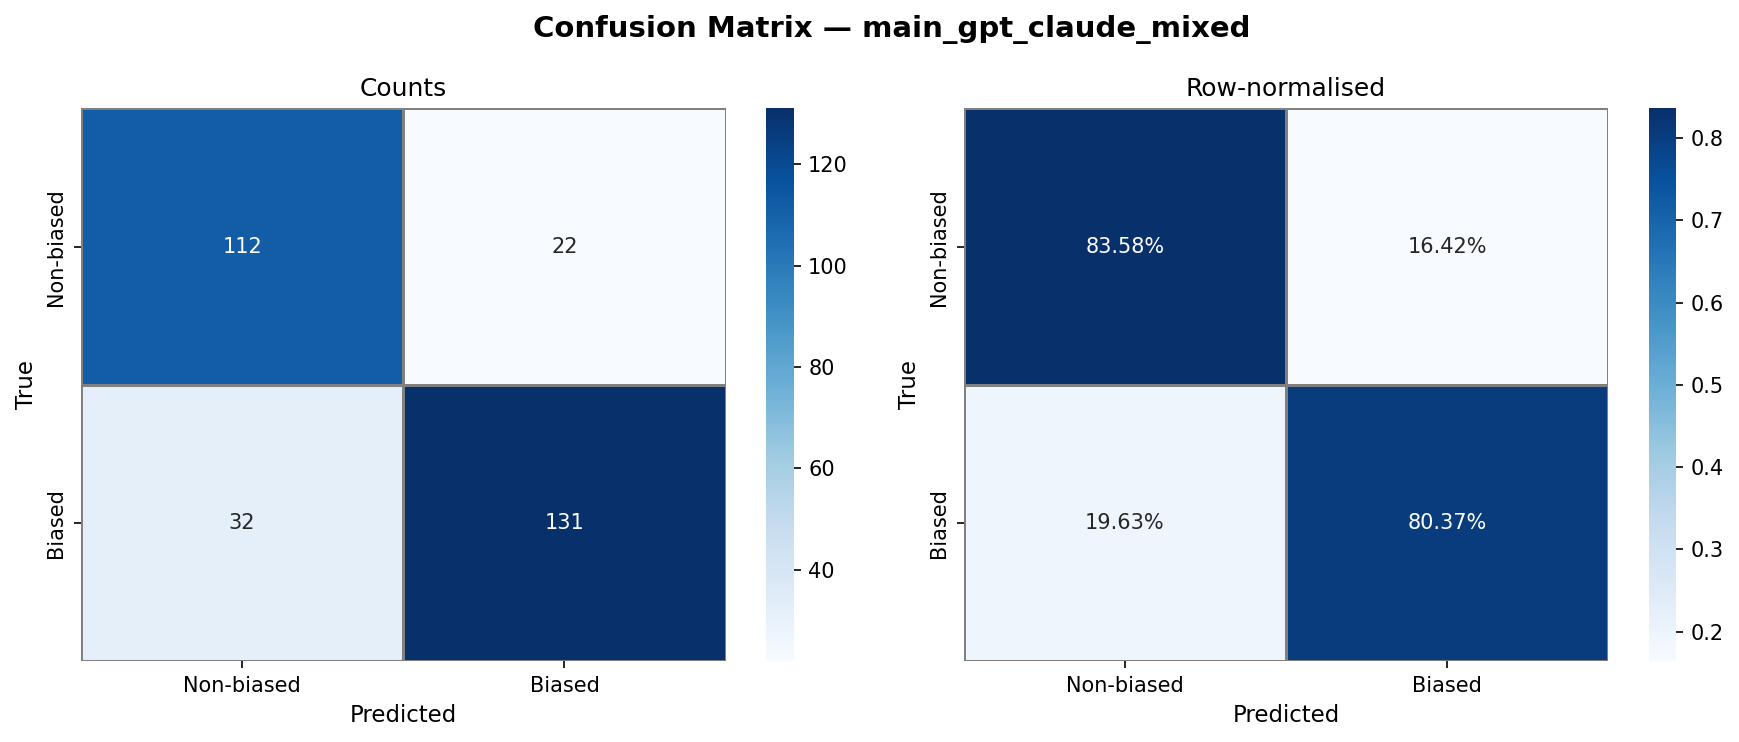

In [10]:
from IPython.display import Image, display
from pathlib import Path
from src.utils import load_config

cfg     = load_config(EXPERIMENT)
cm_path = Path(cfg['output_dir']) / 'confusion_matrix.png'

if cm_path.exists():
    display(Image(str(cm_path)))
else:
    print('⚠️  confusion_matrix.png not found — did evaluate.py run?')

## Cell 10 — Inference on new sentences

In [11]:
import subprocess, sys, tempfile, os
from pathlib import Path

# Add sentences to test here
test_sentences = [
    'أعلنت الحكومة عن خطة اقتصادية جديدة لتحسين مستوى المعيشة.',
    'يسعى الإعلام المتحيز دائماً إلى تشويه الحقائق لخدمة أجندات خاصة.',
    'التقرير يستعرض الأرقام الرسمية دون تعليق.',
]

# Write sentences to a temp file to avoid shell encoding issues with Arabic
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt',
                                  delete=False, encoding='utf-8') as f:
    f.write('\n'.join(test_sentences))
    tmp_path = f.name

result = subprocess.run(
    [sys.executable, 'src/predict.py',
     '--config', EXPERIMENT,
     '--input', tmp_path],
    capture_output=True, text=True
)

os.unlink(tmp_path)  # clean up temp file

if result.returncode != 0:
    print('❌ predict.py failed:')
    print(result.stderr)
else:
    print(result.stdout)

[predict] Loading model from: /content/arabic-bias-detection/outputs/main_gpt_claude_mixed/best_model (device: cuda)
[predict] Classifying 3 sentence(s)...

────────────────────────────────────────────────────────────
🟢 NON-BIASED  (conf=0.1%)
  أعلنت الحكومة عن خطة اقتصادية جديدة لتحسين مستوى المعيشة.

🔴 BIASED  (conf=99.9%)
  يسعى الإعلام المتحيز دائماً إلى تشويه الحقائق لخدمة أجندات خاصة.

🟢 NON-BIASED  (conf=1.2%)
  التقرير يستعرض الأرقام الرسمية دون تعليق.




## Cell 11 — Download output files

In [19]:
from google.colab import files
from pathlib import Path
from src.utils import load_config

cfg = load_config(EXPERIMENT)
out = Path(cfg['output_dir'])

to_download = [
    'metrics.json',
    'classification_report.txt',
    'confusion_matrix.png',
    'predictions.csv',
    'cross_source_metrics.json',   # only present for main_gpt_claude_mixed
]

print('Downloading output files...')
for fname in to_download:
    p = out / fname
    if p.exists():
        files.download(str(p))
        print(f'  ⬇️  {fname}  ({p.stat().st_size // 1024} KB)')
    else:
        print(f'  —  {fname} (not present, skipping)')

  —  metrics.json (not present, skipping)
  —  classification_report.txt (not present, skipping)
  —  confusion_matrix.png (not present, skipping)
  —  predictions.csv (not present, skipping)
  —  cross_source_metrics.json (not present, skipping)
